In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Augmentation

In [2]:
import numpy as np

# Time Masking
def spec_augment_time(mel, time_mask=15):
    mel = mel.copy()

    # Time mask
    t = mel.shape[0]
    t_mask = np.random.randint(0, time_mask)
    t0 = np.random.randint(0, t - t_mask)
    mel[t0:t0 + t_mask, :] = 0

    return mel

# Frequency Masking
def spec_augment_freq(mel, freq_mask=15):
    mel = mel.copy()

    # Frequency mask
    f = mel.shape[1]
    f_mask = np.random.randint(0, freq_mask)
    f0 = np.random.randint(0, f - f_mask)
    mel[:, f0:f0 + f_mask] = 0

    return mel

In [5]:
import librosa
signal, sr = librosa.load("/content/drive/MyDrive/MusicGenreData/classical/classical.00000.wav", sr=22050)
signal = signal[0:66179]
print(signal.shape)
mel = librosa.feature.melspectrogram(y=signal,sr=22050,n_mels= 128)

(66179,)


In [6]:
mel.shape

(128, 130)

#### Before Augmentation

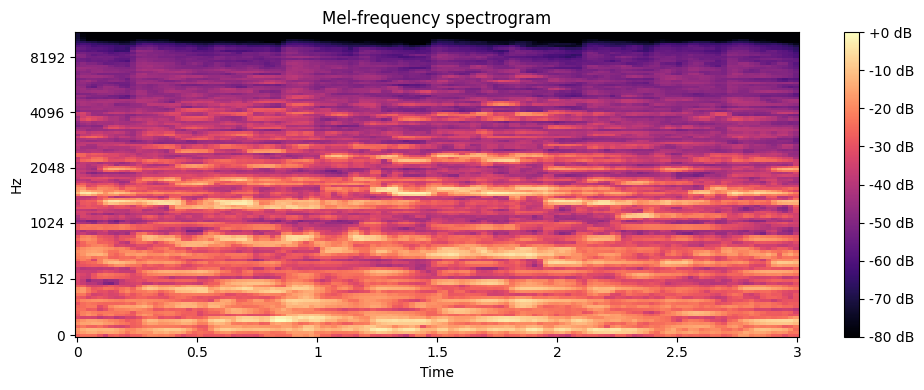

In [7]:
import matplotlib.pyplot as plt
import librosa.display

plt.figure(figsize=(10, 4))
librosa.display.specshow(librosa.power_to_db(mel, ref=np.max), y_axis='mel', x_axis='time')
plt.colorbar(format='%+2.0f dB')
plt.title('Mel-frequency spectrogram')
plt.tight_layout()
plt.show()

#### After Augmentation

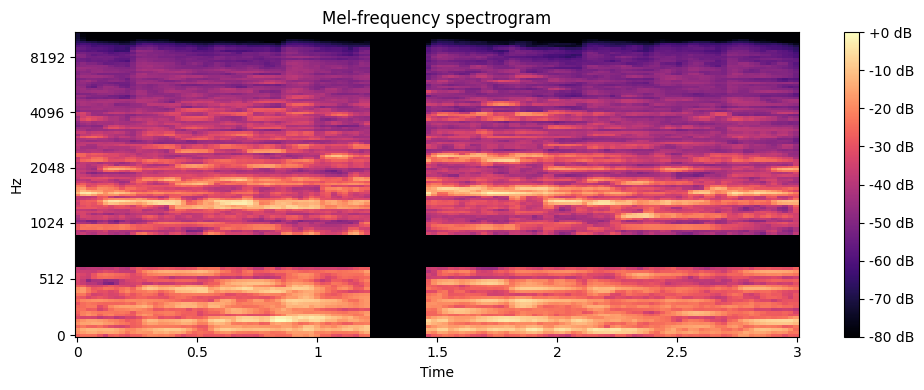

In [8]:
mel_aug = spec_augment_freq(spec_augment_time(mel))

plt.figure(figsize=(10, 4))
librosa.display.specshow(librosa.power_to_db(mel_aug, ref=np.max), y_axis='mel', x_axis='time')
plt.colorbar(format='%+2.0f dB')
plt.title('Mel-frequency spectrogram')
plt.tight_layout()
plt.show()

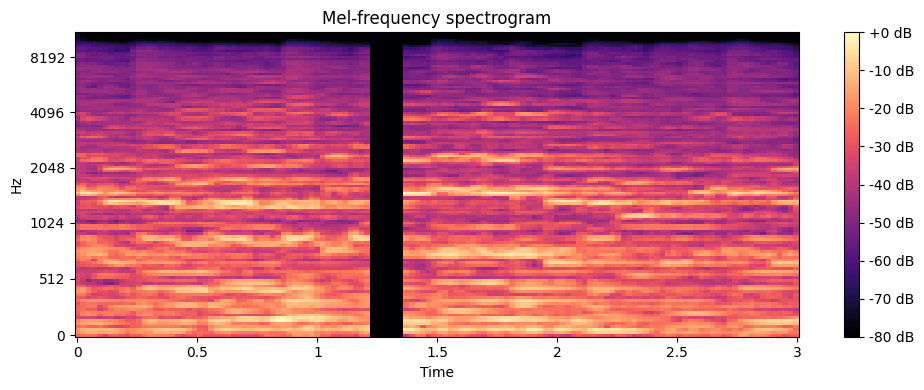

In [9]:
mel_aug2 = spec_augment_freq(mel)

plt.figure(figsize=(10, 4))
librosa.display.specshow(librosa.power_to_db(mel_aug2, ref=np.max), y_axis='mel', x_axis='time')
plt.colorbar(format='%+2.0f dB')
plt.title('Mel-frequency spectrogram')
plt.tight_layout()
plt.show()

### Data Preparation

In [ ]:
import librosa
import numpy as np

def preprocessing(file_path,SAMPLE_RATE=22050,DURATION=3,N_MELS=128,DESIRED_LEN=128):

    samples_per_segment = SAMPLE_RATE * DURATION

    try:
        signal, sr = librosa.load(file_path, sr=SAMPLE_RATE)
    except Exception as e:
        print(f"Error loading file {file_path}: {e}")
        return None

    sample_per_track = signal.shape[0]
    num_segments = max(1, sample_per_track // samples_per_segment)
    mel_segments = []

    for s in range(num_segments):

        start = s * samples_per_segment
        end = start + samples_per_segment

        segment = signal[start:end]

        # pad short segments
        if len(segment) < samples_per_segment:
            segment = librosa.util.fix_length(
                segment,
                size=samples_per_segment
            )

        # Mel Spectrogram
        mel = librosa.feature.melspectrogram(
            y=segment,
            sr=SAMPLE_RATE,
            n_mels=N_MELS
        )

        # Convert to dB
        #mel = librosa.power_to_db(mel, ref=np.max)

        # transpose -> (time, frequency)
        mel = mel.T

        # fix shape
        if mel.shape[0] < DESIRED_LEN:
            pad_width = DESIRED_LEN - mel.shape[0]
            mel = np.pad(
                mel,
                ((0, pad_width), (0, 0)),
                mode='constant')
        else:
            mel = mel[:DESIRED_LEN, :]

        mel_segments.append(mel)

    mel_segments = np.array(mel_segments)

    # add channel dimension
    mel_segments = mel_segments[..., np.newaxis]

    return mel_segments


In [10]:
import numpy as np
import librosa
import os
from preprocessing import preprocessing

DATASET_PATH = "/content/drive/MyDrive/MusicGenreData"

X = []
y = []

for genre in os.listdir(DATASET_PATH):
    genre_path = os.path.join(DATASET_PATH, genre)
    for file in os.listdir(genre_path):
        file_path = os.path.join(genre_path, file)

        mel_segments = preprocessing(file_path)
        if mel_segments is not None:
            # iterate through all segments
            for mel in mel_segments:
                X.append(mel)
                y.append(genre)

/content/preprocessing.py:9: UserWarning: PySoundFile failed. Trying audioread instead.
  signal, sr = librosa.load(file_path, sr=SAMPLE_RATE)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Error loading file /content/drive/MyDrive/MusicGenreData/jazz/jazz.00054.wav: 


In [11]:
import numpy as np
import pandas as pd
x = np.array(X)
y = np.array(y)

In [12]:
x.shape

(9981, 128, 128, 1)

In [13]:
y.shape

(9981,)

In [14]:
# Split
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(x, y, shuffle=True, stratify=y, test_size=0.2)

### Data Augmentation

In [15]:
x_train_aug=[]
y_train_aug = []

for i in range(len(X_train)):
  x_train_aug.append(X_train[i])
  y_train_aug.append(y_train[i])

  x_train_aug.append(spec_augment_freq(spec_augment_time(X_train[i])))
  y_train_aug.append(y_train[i])

  # x_train_aug.append(spec_augment_freq(X_train[i]))
  # y_train_aug.append(y_train[i])

x_train_aug = np.array(x_train_aug)
y_train_aug = np.array(y_train_aug)

In [16]:
x_train_aug.shape

(15968, 128, 128, 1)

In [17]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_train_aug = le.fit_transform(y_train_aug)
y_val = le.transform(y_val)

## Model Training

In [18]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, AvgPool2D, BatchNormalization, Dropout, Dense, GlobalAveragePooling2D

In [23]:
model = Sequential()

model.add(Conv2D(64, (3,3),padding='same', activation='relu', input_shape=(128,128,1)))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.3))

model.add(Conv2D(128, (3,3),padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.3))

model.add(Conv2D(256, (3,3),padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.3))

model.add(Conv2D(512, (3,3),padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.3))

model.add(GlobalAveragePooling2D())

model.add(Dense(128,activation='relu'))
model.add(Dropout(0.4))
model.add(Dense(10, activation='softmax'))


model.compile(optimizer="adam",loss="sparse_categorical_crossentropy",metrics=["accuracy"])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 64)   │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128, 128, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 16, 16, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,620,618 (6.18 MB)

 Trainable params: 1,618,698 (6.17 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [24]:
from tensorflow.keras.callbacks import EarlyStopping

In [25]:
callback = EarlyStopping(monitor="val_accuracy", patience=8, restore_best_weights = True)
history = model.fit(x_train_aug,y_train_aug, epochs = 100, batch_size=32, validation_data=(X_val,y_val),callbacks=callback)

Epoch 1/100
499/499 ━━━━━━━━━━━━━━━━━━━━ 46s 63ms/step - accuracy: 0.4927 - loss: 1.4505 - val_accuracy: 0.3610 - val_loss: 2.3323
Epoch 2/100
499/499 ━━━━━━━━━━━━━━━━━━━━ 28s 57ms/step - accuracy: 0.6693 - loss: 0.9807 - val_accuracy: 0.6455 - val_loss: 1.0114
Epoch 3/100
499/499 ━━━━━━━━━━━━━━━━━━━━ 28s 56ms/step - accuracy: 0.7582 - loss: 0.7325 - val_accuracy: 0.6555 - val_loss: 1.1252
Epoch 4/100
499/499 ━━━━━━━━━━━━━━━━━━━━ 28s 55ms/step - accuracy: 0.8019 - loss: 0.5929 - val_accuracy: 0.8057 - val_loss: 0.5780
Epoch 5/100
499/499 ━━━━━━━━━━━━━━━━━━━━ 41s 56ms/step - accuracy: 0.8396 - loss: 0.4889 - val_accuracy: 0.6009 - val_loss: 1.6109
Epoch 6/100
499/499 ━━━━━━━━━━━━━━━━━━━━ 28s 56ms/step - accuracy: 0.8612 - loss: 0.4085 - val_accuracy: 0.7156 - val_loss: 1.2493
Epoch 7/100
499/499 ━━━━━━━━━━━━━━━━━━━━ 28s 55ms/step - accuracy: 0.8877 - loss: 0.3448 - val_accuracy: 0.7777 - val_loss: 0.8565
Epoch 8/100
499/499 ━━━━━━━━━━━━━━━━━━━━ 28s 56ms/step - accuracy: 0.8979 - loss: 0

accuracy: 0.9717 - loss: 0.0813 - val_accuracy: 0.9364 - val_loss: 0.2524


In [26]:
model.save("music_genre_model2.h5")